## ***Installing libraries 📚***

In [3]:
import math
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
import sklearn.metrics as metrics
from sklearn.model_selection import ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
random_seed = 6

## ***Introduction✨***

### *Why are the k-NN method and decision trees used for this task?* 📝

Decision trees and the k-nearest neighbors (k-NN) method are well-suited for predicting passenger survival on the Titanic as they can effectively handle different types of data, are easy to interpret, and provide insight into which features have the greatest impact on survival. Decision trees clearly visualize decision-making rules, while k-NN identifies local similarities between passengers.

## ***Basic information and analysis about the data.*** 🔍

In [8]:
df = pd.read_csv("/Users/cory/Desktop/01/data.csv")

📝 The dataset (outcomes) contains 13 features:
* ID - A unique identifier for each passenger.
* survived - Indicates whether the passenger survived (0 = No, 1 = Yes).
* pclass - The passenger's class (1 = 1st, 2 = 2nd, 3 = 3rd).
* name - The name of the passenger.
* sex - The gender of the passenger (e.g., male, female).
* age - The age of the passenger.
* sibsp - The number of siblings/spouses the passenger had aboard.
* parch - The number of parents/children the passenger had aboard.
* ticket - The ticket number for the passenger.
* fare - The fare paid by the passenger.
* cabin - The cabin number where the passenger stayed.
* embarked - The port where the passenger embarked (e.g., C = Cherbourg, Q = Queenstown, S = Southampton).
* home.dest - The intended destination of the passenger.

In [10]:
display(df.head())
display(df.shape)
display(df.info())
display(df.nunique())
display(df.describe())
display(df.isnull().sum())

,ID,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest
0,0,0,2,"Baimbrigge, Mr. Charles Robert",male,23.0,0,0,C.A. 31030,10.5000,NaN,S,Guernsey
1,1,0,3,"Aronsson, Mr. Ernst Axel Algot",male,24.0,0,0,349911,7.7750,NaN,S,"Sweden Joliet, IL"
2,2,0,3,"Novel, Mr. Mansouer",male,28.5,0,0,2697,7.2292,NaN,C,NaN
3,3,0,3,"Osen, Mr. Olaf Elon",male,16.0,0,0,7534,9.2167,NaN,S,NaN
4,4,1,2,"Navratil, Master. Michel M",male,3.0,1,1,230080,26.0000,F2,S,"Nice, France"


(1000, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   survived   1000 non-null   int64  
 2   pclass     1000 non-null   int64  
 3   name       1000 non-null   object 
 4   sex        1000 non-null   object 
 5   age        796 non-null    float64
 6   sibsp      1000 non-null   int64  
 7   parch      1000 non-null   int64  
 8   ticket     1000 non-null   object 
 9   fare       1000 non-null   float64
 10  cabin      225 non-null    object 
 11  embarked   1000 non-null   object 
 12  home.dest  573 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


None

ID           1000
survived        2
pclass          3
name          998
sex             2
age            93
sibsp           7
parch           8
ticket        747
fare          260
cabin         155
embarked        3
home.dest     308
dtype: int64

,ID,survived,pclass,age,sibsp,parch,fare
count,1000.000000,1000.000000,1000.000000,796.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,0.373000,2.309000,29.894996,0.522000,0.390000,32.356224
std,288.819436,0.483844,0.835594,14.580693,1.092112,0.877879,50.053812
min,0.000000,0.000000,1.000000,0.166700,0.000000,0.000000,0.000000
25%,249.750000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,499.500000,0.000000,3.000000,28.000000,0.000000,0.000000,14.458300
75%,749.250000,1.000000,3.000000,39.000000,1.000000,0.000000,31.068750
max,999.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


ID             0
survived       0
pclass         0
name           0
sex            0
age          204
sibsp          0
parch          0
ticket         0
fare           0
cabin        775
embarked       0
home.dest    427
dtype: int64

📝 When considering the features that would logically influence survival, the following conclusions can be drawn:
* Gender and passenger class proved to be significant factors affecting the likelihood of survival.
* Women and first-class passengers had significantly higher chances of survival compared to men and passengers in lower classes.

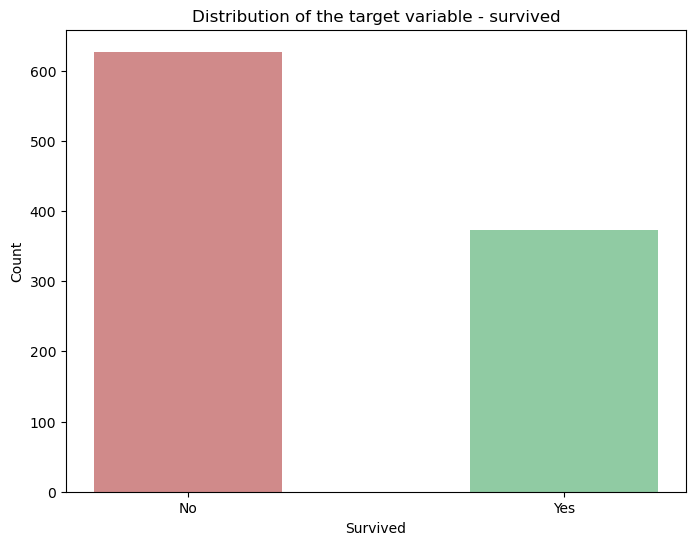

In [12]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
counts = df['survived'].value_counts().sort_index()

colors = ['#D08A8A', '#90CBA3']  
bars = ax1.bar(counts.index, counts.values, width=0.5, color=colors) 

plt.title("Distribution of the target variable - survived")
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])  

plt.show()


In [13]:
display(df['survived'].value_counts())
print()
display(pd.crosstab(df['sex'], df['survived']))
print()
display(pd.crosstab(df['pclass'], df['survived']))
        

survived
0    627
1    373
Name: count, dtype: int64

survived,0,1
sex,,
female,100,253
male,527,120


survived,0,1
pclass,,
1,93,149
2,118,89
3,416,135


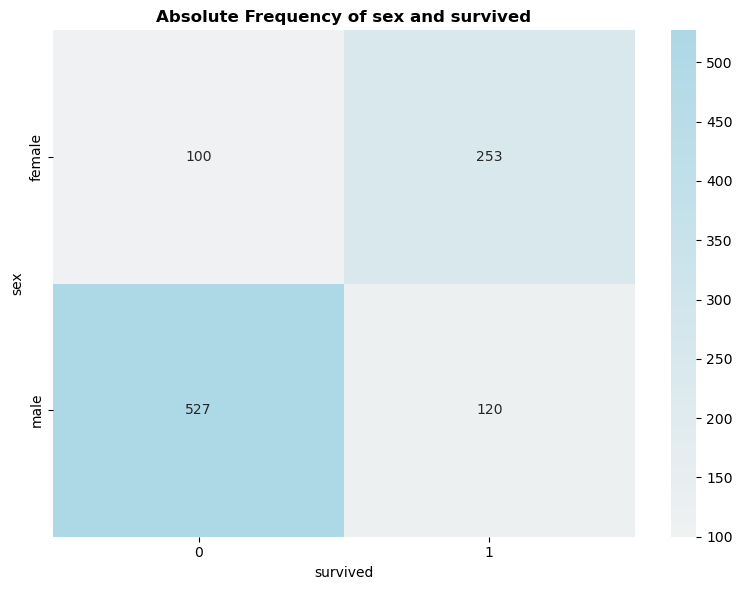

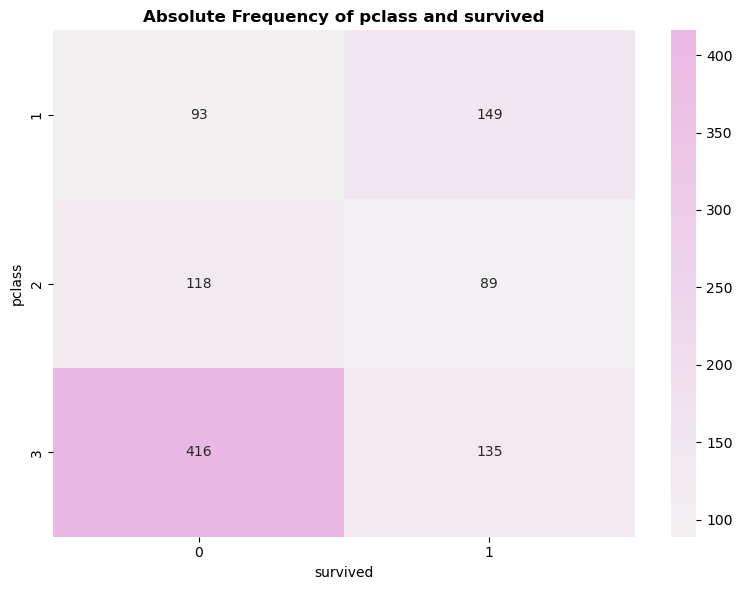

In [14]:
def depend(in_o, a, b, color):
    frequency_table = pd.crosstab(in_o[a], in_o[b])
    fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))  # Create only one subplot
    
    custom_palette_abs = sns.light_palette(color, as_cmap=True)
    sns.heatmap(frequency_table, cmap=custom_palette_abs, annot=True, fmt='g', ax=ax1)
    ax1.set_title(f'Absolute Frequency of {a} and {b}', fontweight='bold')
    ax1.set_xlabel(b)
    ax1.set_ylabel(a)
    
    plt.tight_layout()
    plt.show()

depend(df, 'sex', 'survived', 'lightblue')
depend(df, 'pclass', 'survived', '#EAB8E4')

## ***Convert data 🔄***

📝The ID and name are unique for each record and do not help in predicting the target variable. They do not contain information that could be useful for splitting the data into subgroups. Extracting Titles from Names: Passengers with certain titles, such as Mr., Mrs., Miss., could have different chances of survival.

In [17]:
df['title'] = df['name'].str.extract(r' ([A-Za-z]+)\.', expand=False) 
df.drop(columns=["ID", "name"], inplace=True) #the number of unique values ​​is equal to the number of rows

📝Extracting only the letters allows us to group cabins by deck level, which may have predictive value, while removing extraneous details like numbers or multiple cabin codes that may add noise.

In [19]:
display(df['cabin'].value_counts())
print('======================================')
df['cabin'] = df['cabin'].str.extract('([A-Za-z]+)', expand=False)
df['cabin'].value_counts()

cabin
C23 C25 C27    5
F2             4
D              4
F33            4
B51 B53 B55    3
              ..
A10            1
D46            1
D35            1
C30            1
D45            1
Name: count, Length: 155, dtype: int64

cabin
C    71
B    47
D    33
E    31
A    20
F    19
G     3
T     1
Name: count, dtype: int64

📝Ticket numbers are unique, so it's better to use a more informative feature, such as the length of the ticket number.

In [21]:
display(df['ticket'].value_counts())
print('======================================')
df['ticket'] = df['ticket'].apply(len)
df['ticket'].value_counts()

ticket
CA. 2343    10
1601         7
CA 2144      7
347077       6
347082       6
            ..
350054       1
113787       1
345783       1
11751        1
250650       1
Name: count, Length: 747, dtype: int64

ticket
6     456
5     152
4     108
8      91
10     51
7      29
9      28
11     14
12     14
18     12
13     12
16     11
17     11
15      9
3       2
Name: count, dtype: int64

📝The data in home.dest is very inconsistent, so I reformatted it into a different structure (city (home or dest) or country (home or dest). A more suitable format could have been chosen where the country/city of home and the country/city of destination were recognized and processed separately, but I formatted it in a way that all the data is mixed together.

In [23]:
df['home.dest'] = df['home.dest'].str.split(',').str[-1].str.split('/').str[-1].str.split(' ').str[-1].str.strip()

📝The parameter embarked can be considered ordinal, so we will convert it to a categorical type manually.

In [25]:
#S = Southampton - starting point (first stop).
#C = Cherbourg - next stop after departure (second stop).
#Q = Queenstown - last stop before final departure to sea (third stop).
category_embarked = pd.api.types.CategoricalDtype(categories = ['S','C','Q'],ordered=True)
category_cabin = pd.api.types.CategoricalDtype(categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'],ordered=True)
df['embarked'] = df['embarked'].astype(category_embarked)
df['cabin'] = df['cabin'].astype(category_cabin)
df['title'] = df['title'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   survived   1000 non-null   int64   
 1   pclass     1000 non-null   int64   
 2   sex        1000 non-null   object  
 3   age        796 non-null    float64 
 4   sibsp      1000 non-null   int64   
 5   parch      1000 non-null   int64   
 6   ticket     1000 non-null   int64   
 7   fare       1000 non-null   float64 
 8   cabin      225 non-null    category
 9   embarked   1000 non-null   category
 10  home.dest  573 non-null    object  
 11  title      1000 non-null   category
dtypes: category(3), float64(2), int64(5), object(2)
memory usage: 74.5+ KB


📝Сonvert the categorical ordinal parameters to their numerical equivalents.

In [27]:
cols = df.select_dtypes(['category']).columns
for col in cols:
    df[col] = df[col].cat.codes
df.head()

,survived,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,title
0,0,2,male,23.0,0,0,10,10.5000,-1,0,Guernsey,11
1,0,3,male,24.0,0,0,6,7.7750,-1,0,IL,11
2,0,3,male,28.5,0,0,4,7.2292,-1,1,NaN,11
3,0,3,male,16.0,0,0,4,9.2167,-1,0,NaN,11
4,1,2,male,3.0,1,1,6,26.0000,5,0,France,7


📝Convert all other text flags to categorical + to their numerical equivalents.

In [29]:
df[df.select_dtypes(['object']).columns] = df.select_dtypes(['object']).astype('category')

#Using one-hot encoding for categorical features with many unique values can result in a large table, 
#increasing the dimensionality of the data. This can lead to overfitting (if used on home.dest the table will have over 100 columns).

df['home.dest'] = df['home.dest'].cat.codes 

#One-hot encoding can be used for the sex feature because it is a nominal categorical variable with only two unique values:
#typically "male" and "female." This encoding is efficient in this case, as it will only create a single additional column,
#avoiding high dimensionality and preserving the interpretability of the data.

df = pd.get_dummies(df)
df = df.fillna(-1)

In [30]:
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    1000 non-null   int64  
 1   pclass      1000 non-null   int64  
 2   age         1000 non-null   float64
 3   sibsp       1000 non-null   int64  
 4   parch       1000 non-null   int64  
 5   ticket      1000 non-null   int64  
 6   fare        1000 non-null   float64
 7   cabin       1000 non-null   int8   
 8   embarked    1000 non-null   int8   
 9   home.dest   1000 non-null   int8   
 10  title       1000 non-null   int8   
 11  sex_female  1000 non-null   bool   
 12  sex_male    1000 non-null   bool   
dtypes: bool(2), float64(2), int64(5), int8(4)
memory usage: 60.7 KB


None

,survived,pclass,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,title,sex_female,sex_male
0,0,2,23.0,0,0,10,10.5000,-1,0,26,11,False,True
1,0,3,24.0,0,0,6,7.7750,-1,0,32,11,False,True
2,0,3,28.5,0,0,4,7.2292,-1,1,-1,11,False,True
3,0,3,16.0,0,0,4,9.2167,-1,0,-1,11,False,True
4,1,2,3.0,1,1,6,26.0000,5,0,23,7,False,True


❗Subsequent changes (adding or removing features) will be made later, during the development of a more accurate model.

## ***Data splitting*** 🧩

In [33]:
def splitting(df, target_column='survived', test_size=0.4, val_test_split=0.5):
    # Split the training dataset into 60% train and 40% rest
    Xtrain, Xrest, ytrain, yrest = train_test_split(
        df.drop(columns=[target_column]), 
        df[target_column], 
        test_size=test_size, 
        random_state=random_seed
    )

    # Split the rest of the data into 20% validation and 20% test
    Xval, Xtest, yval, ytest = train_test_split(
        Xrest, 
        yrest, 
        test_size=val_test_split, 
        random_state=random_seed
    )
    
    # Return all data splits
    return Xtrain, Xval, Xtest, ytrain, yval, ytest

# Example call to the function
Xtrain, Xval, Xtest, ytrain, yval, ytest = splitting(df)


## ***Hyperparameter tuning***🔧
### Decision Tree model 🌳

📝 Selecting parameters without cross validation

In [36]:
val_acc = []
train_acc = []
param_grid = {
    'max_depth': range(1,30), 
    'criterion': ['entropy', 'gini']
}
param_comb = ParameterGrid(param_grid)
for param in param_comb:
    clf = DecisionTreeClassifier(max_depth=param['max_depth'], criterion=param['criterion'], random_state = random_seed)
    clf.fit(Xtrain, ytrain)
    train_acc.append(metrics.accuracy_score(ytrain, clf.predict(Xtrain)))
    val_acc.append(metrics.accuracy_score(yval, clf.predict(Xval)))
best_param = param_comb[np.argmax(val_acc)]

clf = DecisionTreeClassifier(max_depth = best_param['max_depth'], criterion=best_param['criterion'], random_state = random_seed).fit(Xtrain, ytrain)

print(f"Best criterion: {best_param['criterion']}, best depth: {best_param['max_depth']}")
print('Accuracy score (val): {0:.6f}'.format(metrics.accuracy_score(yval, clf.predict(Xval))))
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain, clf.predict(Xtrain))))


Best criterion: gini, best depth: 10
Accuracy score (val): 0.805000
Accuracy score (train): 0.940000


📝 *Graph analysis*
* Overfitting: The graph clearly shows that as the hyperparameter index increases, the model achieves high accuracy on the training data (the line reaches 1.0), while the accuracy on the validation data deteriorates (the line declines). This is a classic sign of overfitting.
  
* Optimal choice of hyperparameters: The likely optimal range for the hyperparameters is where the validation accuracy was at its peak (around index 3-6). Beyond this point, the data points indicate that the increasing complexity of the model leads to a decrease in its generalization ability.



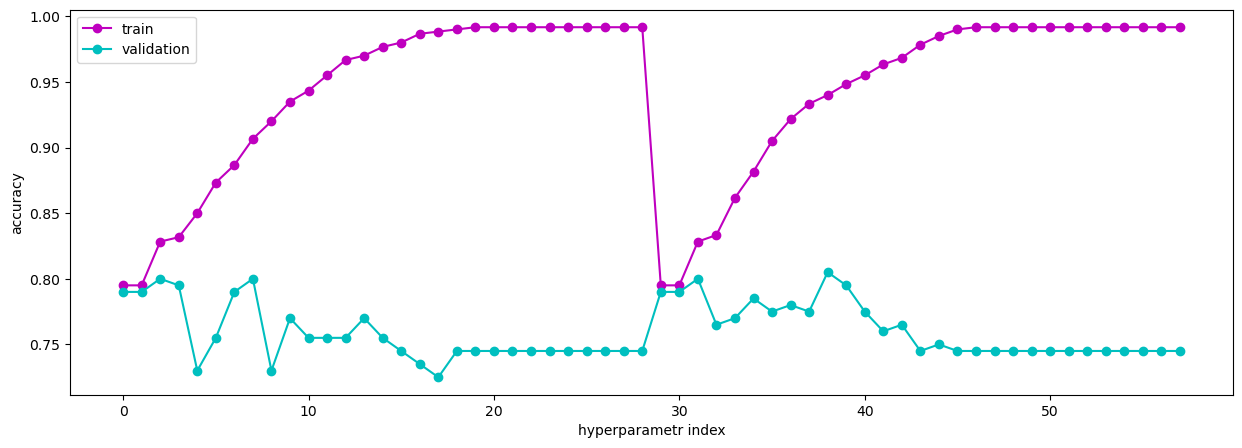

In [38]:
plt.figure(figsize=(15,5))
plt.plot(train_acc,'om-')
plt.plot(val_acc,'oc-')
plt.xlabel('hyperparametr index')
plt.ylabel('accuracy')
plt.legend(['train', 'validation'])

📝 Selecting parameters with cross validation

In [40]:
def tuning (Xtrain, ytrain):
    param_grid = {
        'max_depth': range(1,30), 
        'criterion': ['entropy', 'gini']
    }
    param_comb = ParameterGrid(param_grid)
    val_metric = []
    splits = 10
    for params in param_comb:
        clf = DecisionTreeClassifier(max_depth=params['max_depth'], criterion=params['criterion'], random_state = random_seed)
        #cross validation
        kf = KFold(n_splits = splits)
        fold_acc = []
        for train_i, val_i in kf.split(Xtrain):
            tXtrain, tXval = Xtrain.iloc[train_i,:], Xtrain.iloc[val_i,:]
            tytrain,tyval = ytrain.iloc[train_i], ytrain.iloc[val_i]
            clf.fit(tXtrain, tytrain)
            fold_acc.append(metrics.accuracy_score(tyval, clf.predict(tXval)))

        val_metric.append(np.mean(fold_acc))
    best_tree_params = param_comb[np.argmax(val_metric)]
    best_tree_metric = max(val_metric)
    print(f"best tree params: {best_tree_params}, best tree metric: {best_tree_metric:.4f}.")
    return best_tree_params, best_tree_metric


best_tree_params, best_tree_metric = tuning(Xtrain, ytrain)
print('=======================================')
clf = DecisionTreeClassifier(max_depth = best_tree_params['max_depth'], criterion=best_tree_params['criterion'], random_state = random_seed).fit(Xtrain, ytrain)
print('Accuracy score (val): {0:.6f}'.format(metrics.accuracy_score(yval, clf.predict(Xval))))
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain, clf.predict(Xtrain))))


best tree params: {'max_depth': 3, 'criterion': 'gini'}, best tree metric: 0.8167.
Accuracy score (val): 0.800000
Accuracy score (train): 0.828333


📝 I chose the cross-validation parameters despite slightly lower accuracy because they provide a more reliable and generalizable model. Cross-validation reduces the risk of overfitting and ensures the model performs consistently on unseen data, prioritizing stability over potentially misleading higher training accuracy.
In the future, parameters will be selected using cross-validation, so I decided to create a function for this.

## ***Feature selection***🧬

📝To choose a more effective model, I decided to create several variations of the initial data and observe how this affects the results.
I will add features, specifically:

* Adding a new feature: age category
* Combining the features sibsp and parch into one family feature (with and without removing the original features)

In [44]:
df['age_category'] = pd.cut(df['age'], bins=[0, 12, 59, float('inf')], labels=['child', 'adult', 'elderly'])
df['age_category'] = df['age_category'].astype(pd.CategoricalDtype(categories=['child', 'adult', 'elderly'], ordered=True))
df['age_category'] = df['age_category'].cat.codes
df.head()

,survived,pclass,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,title,sex_female,sex_male,age_category
0,0,2,23.0,0,0,10,10.5000,-1,0,26,11,False,True,1
1,0,3,24.0,0,0,6,7.7750,-1,0,32,11,False,True,1
2,0,3,28.5,0,0,4,7.2292,-1,1,-1,11,False,True,1
3,0,3,16.0,0,0,4,9.2167,-1,0,-1,11,False,True,1
4,1,2,3.0,1,1,6,26.0000,5,0,23,7,False,True,0


In [45]:
Xtrain1, Xval1, Xtest1, ytrain1, yval1, ytest1 = splitting(df)
display(Xtrain.head())
best_tree_params, best_tree_metric = tuning(Xtrain1, ytrain1)
print('=======================================')
clf = DecisionTreeClassifier(max_depth = best_tree_params['max_depth'], criterion=best_tree_params['criterion'], random_state = random_seed).fit(Xtrain1, ytrain1)
print('Accuracy score (val): {0:.6f}'.format(metrics.accuracy_score(yval1, clf.predict(Xval1))))
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain1, clf.predict(Xtrain1))))



,pclass,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,title,sex_female,sex_male
323,1,23.0,1,0,5,113.2750,3,1,41,8,True,False
949,3,-1.0,0,0,6,7.8958,-1,0,-1,11,False,True
944,1,61.0,0,0,6,33.5000,1,0,58,11,False,True
421,1,36.0,0,2,9,71.0000,1,0,86,8,True,False
887,3,-1.0,0,0,6,7.8292,-1,2,-1,11,False,True


best tree params: {'max_depth': 3, 'criterion': 'gini'}, best tree metric: 0.8167.
Accuracy score (val): 0.800000
Accuracy score (train): 0.828333


📝 After adding a new feature, the model didn't change.
It is likely due to the high correlation between `age` and `age_category`: since `age_category` is created based on the values ​​from `age`, it essentially conveys the same information. It can also be seen from the graph below the importance of different features. 

In [47]:
Xtrain2, Xval2, Xtest2, ytrain2, yval2, ytest2 = splitting(df)
display(Xtrain.head())
best_tree_params, best_tree_metric = tuning(Xtrain2, ytrain2)
print('=======================================')
clf = DecisionTreeClassifier(max_depth = best_tree_params['max_depth'], criterion=best_tree_params['criterion'], random_state = random_seed).fit(Xtrain2, ytrain2)
print('Accuracy score (val): {0:.6f}'.format(metrics.accuracy_score(yval2, clf.predict(Xval2))))
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain2, clf.predict(Xtrain2))))


,pclass,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,title,sex_female,sex_male
323,1,23.0,1,0,5,113.2750,3,1,41,8,True,False
949,3,-1.0,0,0,6,7.8958,-1,0,-1,11,False,True
944,1,61.0,0,0,6,33.5000,1,0,58,11,False,True
421,1,36.0,0,2,9,71.0000,1,0,86,8,True,False
887,3,-1.0,0,0,6,7.8292,-1,2,-1,11,False,True


best tree params: {'max_depth': 3, 'criterion': 'gini'}, best tree metric: 0.8167.
Accuracy score (val): 0.800000
Accuracy score (train): 0.828333


📝For further work, so as not to work blindly, I made a heat map to roughly understand where to go to improve the model. <br>

The following conclusions can be drawn from the heat map:
* The `sex_female` feature has a high positive correlation with `survived` (0.52), indicating that gender (female) could be an important factor in predicting survival. 

* The `cabin` feature has a strong negative correlation with `pclass` (-0.74), suggesting a connection between class and the availability of cabin data.

* The `age_category` feature has a high correlation with `age` (0.83), confirming that they convey similar information.

Conclusion :
1) removal of redundant features
2) creating complex interactions between signs that have a high correlation with survivors
    

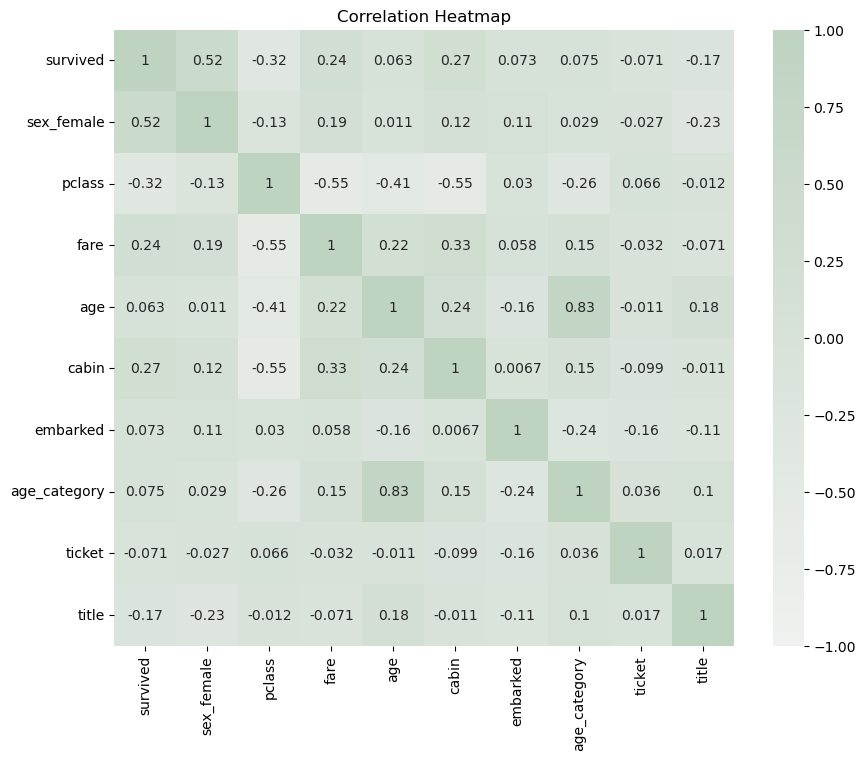

In [49]:
features_for_heatmap = ['survived', 'sex_female', 'pclass', 'fare', 'age','cabin', 'embarked', 'age_category', 'ticket','title']
custom_palette_abs = sns.light_palette('#BFD3C1', as_cmap=True)
plt.figure(figsize=(10, 8))
correlation_matrix = df[features_for_heatmap].corr()
sns.heatmap(correlation_matrix, annot=True, cmap=custom_palette_abs, vmin=-1, vmax=1)

plt.title('Correlation Heatmap') 
plt.show()


📝 When new parameters were added, the accuracy on the training data increased, but the accuracy on the validation data decreased. This likely indicates that adding new parameters contributes to overfitting. Additionally, when parameters that initially seemed to be of little value were removed, the model's accuracy decreased (probably because those 0.00...01 values positively influenced the model's accuracy). Conclusion: I kept the original model without adding new parameters.


❗Perhaps these features will be useful in kNN

In [52]:
#df['fare_per_age'] = df['fare'] / (df['age'] + 2) 
#df['ticket_cabin'] = df['ticket'].astype(str)
#df['age_family'] = (df['age'] * df['family']).astype(int) #(10)
#df['fare_class_ratio'] = df['fare'] / (df['pclass'] + 1)
#df['age_sex_interaction'] = df['sex_female'].astype(str) + '_' + pd.cut(df['age'], bins=[0, 18, 60, 100], labels=['child', 'adult', 'elderly']).astype(str)
#df['group_size'] = df['sibsp'] + df['parch'] + 1  
#df['family_pclass'] = df['family'].astype(str) + '_' + df['pclass'].astype(str)
#df = pd.get_dummies(df)
#df['family'] = df['sibsp'] + df['parch']
#df['family'] = (df['family'] > 0).astype(int)


## ***Final version of a Decision Tree model*** 🌳

In [54]:
Xtrain2, Xval2, Xtest2, ytrain2, yval2, ytest2 = splitting(df)
print('=======================================')
best_tree_params, best_tree_metric = tuning(Xtrain2, ytrain2)
print('=======================================')
clf = DecisionTreeClassifier(max_depth = best_tree_params['max_depth'], criterion=best_tree_params['criterion'], random_state = random_seed).fit(Xtrain2, ytrain2)
print('Accuracy score (val): {0:.6f}'.format(metrics.accuracy_score(yval2, clf.predict(Xval2))))
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain2, clf.predict(Xtrain2))))
print('=======================================')



best tree params: {'max_depth': 3, 'criterion': 'gini'}, best tree metric: 0.8167.
Accuracy score (val): 0.800000
Accuracy score (train): 0.828333


## ***ROC curve and AUC***📈

📝 (I took this graph from the fifth Jupiter notebook.) AUC = 0.839 indicates that the model is significantly better than random guessing (AUC = 0.5) and is capable of effectively distinguishing between classes.
The model, overall, demonstrated good performance.

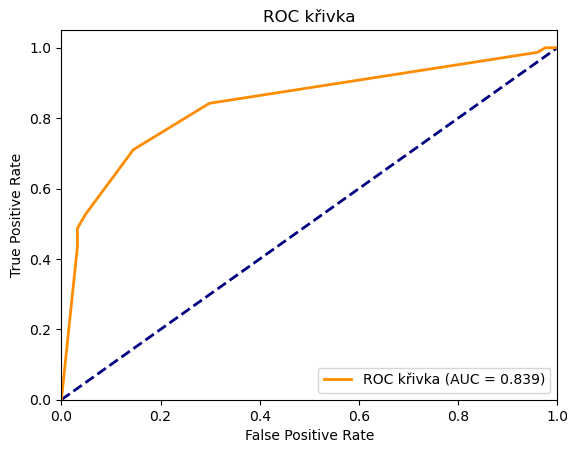

In [57]:
y_pred_proba = clf.predict_proba(Xval2)
p1_hat = y_pred_proba[:,1]

fpr, tpr, thresholds = metrics.roc_curve(yval2, p1_hat)

AUC = metrics.roc_auc_score(yval2, y_pred_proba[:,1])

plt.figure()
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC křivka (AUC = {AUC:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivka")
plt.legend(loc="lower right")
plt.show()

📝 The F1 score (val) = 0.729730 indicates that the model demonstrates a balanced relationship between accuracy and recall when making predictions on the validation set.

In [59]:
y_pred_val = clf.predict(Xval2)
f1_val = metrics.f1_score(yval2, y_pred_val, average='binary')
print('F1 score (val): {0:.6f}'.format(f1_val))

F1 score (val): 0.729730


In [60]:
cfDT = metrics.confusion_matrix(ytest2, clf.predict(Xtest2))

print("decision trees")
print(cfDT)

decision trees
[[106  24]
 [ 17  53]]


## ***KNearestNeighbors*** 👥


In [62]:
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
Xtrain1, Xval1, Xtest1, ytrain1, yval1, ytest1 = splitting(df_normalized)

param_grid = {
    "n_neighbors": range(1, 15),
    "metric": ["euclidean", "manhattan", "chebyshev", "minkowski"],
}
param_comb = ParameterGrid(param_grid)

val_metric = []
for params in param_comb:
    clfK1 = KNeighborsClassifier(**params)
    fold_acc = cross_val_score(clfK1, Xtrain1, ytrain1, cv=5)
    val_metric.append(np.mean(fold_acc))

best_knn_params = param_comb[np.argmax(val_metric)]
best_knn_metric = max(val_metric)
print(f"Best knn_params: {best_knn_params} with cross-validation accuracy {best_knn_metric:.4f}.")

clfK = KNeighborsClassifier(**best_knn_params)
clfK.fit(Xtrain1, ytrain1)

val_score = metrics.accuracy_score(yval1, clfK.predict(Xval1))
train_score = metrics.accuracy_score(ytrain1, clfK.predict(Xtrain1))

print('Accuracy score (val): {0:.6f}'.format(val_score))
print('Accuracy score (train): {0:.6f}'.format(train_score))

Best knn_params: {'n_neighbors': 8, 'metric': 'manhattan'} with cross-validation accuracy 0.8150.
Accuracy score (val): 0.805000
Accuracy score (train): 0.836667


In [63]:
#df['fare_per_age'] = df['fare'] / (df['age'] + 2) 
#df['ticket_cabin'] = df['ticket'].astype(str)
#df['fare_class_ratio'] = df['fare'] / (df['pclass'] + 1)
#df['age_sex_interaction'] = df['sex_female'].astype(str) + '_' + pd.cut(df['age'], bins=[0, 18, 60, 100], labels=['child', 'adult', 'elderly']).astype(str)
#df['group_size'] = df['sibsp'] + df['parch'] + 1  
#df['family'] = df['sibsp'] + df['parch']
#df['family'] = (df['family'] > 0).astype(int)
#df['family_pclass'] = df['family'].astype(str) + '_' + df['pclass'].astype(str)
#df['age_family'] = (df['age'] * df['family']).astype(int) 
#df = pd.get_dummies(df)


📝 Although adding new parameters improves the accuracy on the training set and slightly enhances the value on the validation set, the difference between them becomes too large, which may indicate overfitting.

## ***Final version of a kNN model*** 👥

In [66]:
clfK = KNeighborsClassifier(**best_knn_params)
clfK.fit(Xtrain1, ytrain1)
val_score = metrics.accuracy_score(yval1, clfK.predict(Xval1))
train_score = metrics.accuracy_score(ytrain1, clfK.predict(Xtrain1))
print(f"Best knn_params: {best_knn_params} with cross-validation accuracy {best_knn_metric:.4f}.")

print('Accuracy score (val): {0:.6f}'.format(val_score))
print('=======================================')
print('Accuracy score (train): {0:.6f}'.format(train_score))
print('=======================================')

Best knn_params: {'n_neighbors': 8, 'metric': 'manhattan'} with cross-validation accuracy 0.8150.
Accuracy score (val): 0.805000
Accuracy score (train): 0.836667


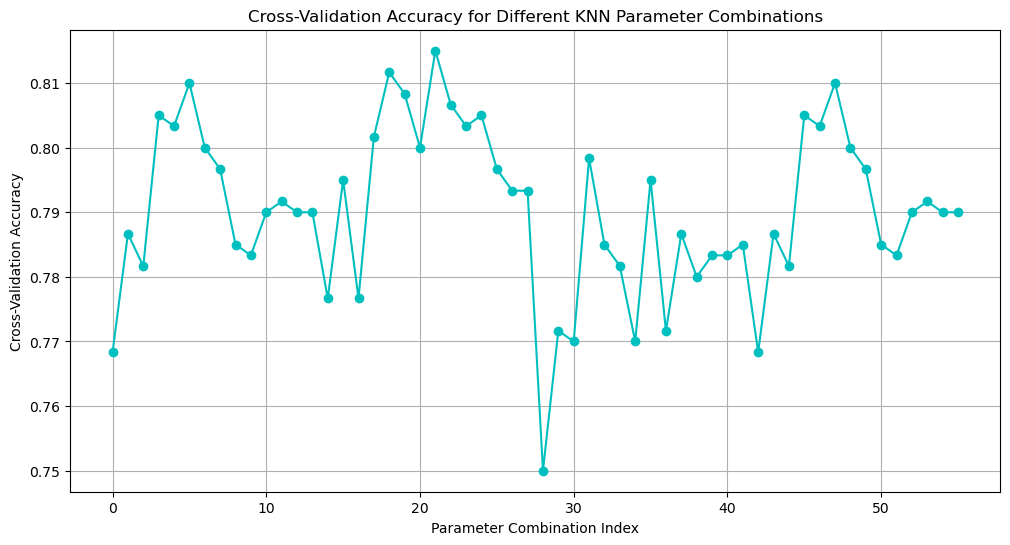

In [67]:
param_grid = {
    "n_neighbors": range(1, 15),
    "metric": ["euclidean", "manhattan", "chebyshev", "minkowski"],
}
param_comb = list(range(len(val_metric))) 


plt.figure(figsize=(12, 6))
plt.plot(param_comb, val_metric, marker='o', linestyle='-', color='c')
plt.xlabel("Parameter Combination Index")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Cross-Validation Accuracy for Different KNN Parameter Combinations")
plt.grid(True)
plt.show()



## ***ROC curve and AUC***📈

📝 The model shows good performance with an AUC of 0.825 and an F1 score of 0.69, indicating effective class distinction and a balance between precision and recall.

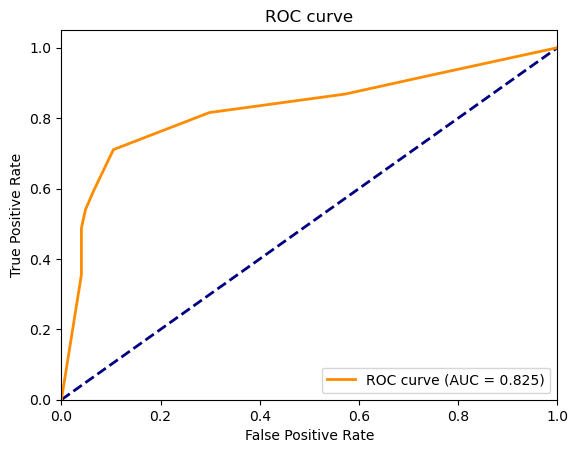

In [70]:
y_pred_proba = clfK.predict_proba(Xval1)
p1_hat = y_pred_proba[:,1]

fpr, tpr, thresholds = metrics.roc_curve(yval1, p1_hat)

AUC = metrics.roc_auc_score(yval1, y_pred_proba[:,1])

plt.figure()
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC curve (AUC = {AUC:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.show()

In [71]:
y_pred_val = clfK.predict(Xval1)
f1_val = metrics.f1_score(yval1, y_pred_val, average='binary')
print('F1 score (val): {0:.6f}'.format(f1_val))

F1 score (val): 0.697674


## ***Сonfusion matrix ⚖️***

📝 Both models have their strengths and weaknesses, with decision trees leaning more towards overall balanced classification, while kNN shows stronger identification of positive cases but at the cost of increased false negatives.

In [74]:
cfDT = metrics.confusion_matrix(ytest2, clf.predict(Xtest2))

print("decision trees")
print(cfDT)

cfKNN = metrics.confusion_matrix(ytest1, clfK.predict(Xtest1))
print("\nkNN")
print(cfKNN)

decision trees
[[106  24]
 [ 17  53]]

kNN
[[116  14]
 [ 28  42]]


## ***Final model***🏁

Best tree params: {'max_depth': 3, 'criterion': 'gini'}, best tree metric: 0.8167.

* Accuracy score (val): 0.800000
* Accuracy score (train): 0.828333
* AUC = 0.839
* F1 score = 0.729730
* [[106  24],[ 17  53]]




Best knn_params: {'n_neighbors': 8, 'metric': 'manhattan'} with cross-validation accuracy 0.8150.

* Accuracy score (val): 0.805000
* Accuracy score (train): 0.836667
* AUC of 0.825 
* F1 score 0.697674
* [[116  14], [ 28  42]]


📝 In general, the models produce approximately the same results. However, since `KNN` showed higher accuracy on the validation set, it is likely to be slightly more accurate on the test set as well.

In [78]:
print('Accuracy score (val): {0:.6f}'.format(metrics.accuracy_score(yval1, clfK.predict(Xval1))))
print('Accuracy score (test): {0:.6f}'.format(metrics.accuracy_score(ytest1, clfK.predict(Xtest1))))

Accuracy score (val): 0.805000
Accuracy score (test): 0.790000


**✨✨✨Overall Conclusion✨✨✨**: The model with parameters ` {'n_neighbors': 8, 'metric': 'manhattan'}'` demonstrates stable and consistent results across all datasets (training, validation, and test sets). The accuracy on the test set (0.790) and the validation set (0.805) indicates that the model generalizes well to new data and has adequate complexity to avoid overfitting. Given that the data format remains unchanged, a similar accuracy range between 78% and 81% can be expected on new test data, considering potential random fluctuations. A significant drop in accuracy below 75% is unlikely.

## ***Last Steps🚀🚀🚀***

In [81]:
df = pd.read_csv("/Users/cory/Desktop/01/evaluation.csv")

In [82]:
df['title'] = df['name'].str.extract(r' ([A-Za-z]+)\.', expand=False) 
df.drop(columns=["ID", "name"], inplace=True) 

df['cabin'] = df['cabin'].str.extract('([A-Za-z]+)', expand=False)

df['ticket'] = df['ticket'].apply(len)
df['home.dest'] = df['home.dest'].str.split(',').str[-1].str.split('/').str[-1].str.split(' ').str[-1].str.strip()


category_embarked = pd.api.types.CategoricalDtype(categories = ['S','C','Q'],ordered=True)
category_cabin = pd.api.types.CategoricalDtype(categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'],ordered=True)
df['embarked'] = df['embarked'].astype(category_embarked)
df['cabin'] = df['cabin'].astype(category_cabin)
df['title'] = df['title'].astype('category')

cols = df.select_dtypes(['category']).columns
for col in cols:
    df[col] = df[col].cat.codes

df[df.select_dtypes(['object']).columns] = df.select_dtypes(['object']).astype('category')


df['home.dest'] = df['home.dest'].cat.codes 


df = pd.get_dummies(df)
df = df.fillna(-1)
df['age_category'] = pd.cut(df['age'], bins=[0, 12, 59, float('inf')], labels=['child', 'adult', 'elderly'])
df['age_category'] = df['age_category'].astype(pd.CategoricalDtype(categories=['child', 'adult', 'elderly'], ordered=True))
df['age_category'] = df['age_category'].cat.codes


scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df_normalized

,pclass,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest,title,sex_female,sex_male,age_category
0,0.5,0.303030,0.000,0.000000,0.133333,0.022403,0.000000,0.333333,0.500000,0.666667,0.0,1.0,0.666667
1,0.5,0.500000,0.125,0.000000,0.066667,0.052598,0.000000,0.333333,0.592593,0.666667,0.0,1.0,0.666667
2,1.0,0.931818,0.000,0.000000,0.066667,0.000000,0.000000,0.333333,0.000000,0.666667,0.0,1.0,1.000000
3,0.5,0.742424,0.125,0.333333,0.200000,0.128572,0.000000,0.333333,0.555556,0.777778,1.0,0.0,0.666667
4,0.0,0.000000,0.000,0.000000,0.200000,0.079092,0.000000,0.666667,0.703704,0.000000,0.0,1.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0.0,0.742424,0.125,0.000000,0.333333,0.151422,0.571429,0.666667,0.592593,0.666667,0.0,1.0,0.666667
305,0.5,0.530303,0.000,0.000000,0.200000,0.027273,0.571429,0.333333,0.370370,0.666667,0.0,1.0,0.666667
306,0.0,0.893939,0.000,0.000000,0.333333,0.287380,0.285714,0.666667,0.000000,0.444444,1.0,0.0,0.666667
307,1.0,0.424242,0.000,0.333333,0.200000,0.023636,0.000000,0.333333,0.000000,0.777778,1.0,0.0,0.666667


In [83]:
predictions = clfK.predict(df_normalized)
df1 = pd.read_csv("/Users/cory/Desktop/01/evaluation.csv")
output_df = pd.DataFrame({
    'ID': df1['ID'], 
    'survived': predictions  
})

output_df.to_csv('results.csv', index=False)
import os
print(os.getcwd())

/Users/cory


## ***Sources: 📖***

* BI-VIZ/BI-ML1 Lectures, presentations, Jupyter Notebooks
* Wikipedia
* https://seaborn.pydata.org
* https://matplotlib.org
* https://chatgpt.com
* https://scikit-learn.org